In [1]:
# E-commerce Sales Analysis — Day 5: Operations and Delivery Performance
# Author: Rohan Vishwakarma

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

DATA_DIR = Path('../data/raw')

# Load the tables we need
orders = pd.read_csv(DATA_DIR / 'olist_orders_dataset.csv')
order_items = pd.read_csv(DATA_DIR / 'olist_order_items_dataset.csv')
customers = pd.read_csv(DATA_DIR / 'olist_customers_dataset.csv')
reviews = pd.read_csv(DATA_DIR / 'olist_order_reviews_dataset.csv')
products = pd.read_csv(DATA_DIR / 'olist_products_dataset.csv')
category_translation = pd.read_csv(DATA_DIR / 'product_category_name_translation.csv')

print("Data loaded ✅")
print(f"orders: {orders.shape}")
print(f"reviews: {reviews.shape}")

Data loaded ✅
orders: (99441, 8)
reviews: (99224, 7)


In [2]:
# Convert all date columns to datetime
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

# Quick check
print("Date columns converted ✅")
print(orders[date_cols].dtypes)

Date columns converted ✅
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object


In [3]:
# We can only analyze delivery performance for orders that were actually delivered
print("Order status breakdown:")
print(orders['order_status'].value_counts())

# Filter to delivered orders with valid delivery dates
delivered = orders[
    (orders['order_status'] == 'delivered') & 
    (orders['order_delivered_customer_date'].notna())
].copy()

print(f"\nTotal delivered orders with valid dates: {len(delivered):,}")
print(f"% of all orders: {len(delivered) / len(orders) * 100:.1f}%")

Order status breakdown:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Total delivered orders with valid dates: 96,470
% of all orders: 97.0%


In [4]:
# Calculate three key delivery metrics

# 1. Actual delivery time (days from purchase to delivery)
delivered['actual_delivery_days'] = (
    delivered['order_delivered_customer_date'] - delivered['order_purchase_timestamp']
).dt.days

# 2. Estimated delivery time (days from purchase to promised delivery)
delivered['estimated_delivery_days'] = (
    delivered['order_estimated_delivery_date'] - delivered['order_purchase_timestamp']
).dt.days

# 3. Delivery delay (positive = late, negative = early)
delivered['delivery_delay_days'] = (
    delivered['actual_delivery_days'] - delivered['estimated_delivery_days']
)

# Flag late deliveries
delivered['is_late'] = delivered['delivery_delay_days'] > 0

print("Delivery metrics calculated ✅")
print(f"\nSample of computed metrics:")
print(delivered[
    ['actual_delivery_days', 'estimated_delivery_days', 'delivery_delay_days', 'is_late']
].head())

Delivery metrics calculated ✅

Sample of computed metrics:
   actual_delivery_days  estimated_delivery_days  delivery_delay_days  is_late
0                     8                       15                   -7    False
1                    13                       19                   -6    False
2                     9                       26                  -17    False
3                    13                       26                  -13    False
4                     2                       12                  -10    False


In [5]:
# Join customer state for regional analysis
delivered = delivered.merge(
    customers[['customer_id', 'customer_state']], 
    on='customer_id', 
    how='left'
)

# Get a representative category per order
# (orders can have multiple items; we'll use the first item's category)
order_categories = (
    order_items
    .merge(products[['product_id', 'product_category_name']], on='product_id', how='left')
    .merge(category_translation, on='product_category_name', how='left')
    .groupby('order_id')['product_category_name_english']
    .first()
    .reset_index()
)

delivered = delivered.merge(order_categories, on='order_id', how='left')

print(f"Dataset ready for analysis: {delivered.shape}")
print(f"Sample of joined data:")
print(delivered[['order_id', 'customer_state', 'product_category_name_english', 
                  'actual_delivery_days', 'is_late']].head())

Dataset ready for analysis: (96470, 14)
Sample of joined data:
                           order_id customer_state product_category_name_english  actual_delivery_days  is_late
0  e481f51cbdc54678b7cc49136f2d6af7             SP                    housewares                     8    False
1  53cdb2fc8bc7dce0b6741e2150273451             BA                     perfumery                    13    False
2  47770eb9100c2d0c44946d9cf07ec65d             GO                          auto                     9    False
3  949d5b44dbf5de918fe9c16f97b45f8a             RN                      pet_shop                    13    False
4  ad21c59c0840e6cb83a9ceb5573f8159             SP                    stationery                     2    False


In [6]:
print("DELIVERY PERFORMANCE OVERVIEW")
print("=" * 60)

# Actual delivery time distribution
print("\nActual delivery time (days):")
print(delivered['actual_delivery_days'].describe().round(1))

# Estimated delivery time distribution
print("\nEstimated delivery time (days):")
print(delivered['estimated_delivery_days'].describe().round(1))

# Delivery delay
print("\nDelivery delay (negative = early, positive = late):")
print(delivered['delivery_delay_days'].describe().round(1))

# Late delivery rate
late_rate = delivered['is_late'].mean() * 100
print(f"\n% of orders delivered late: {late_rate:.1f}%")
print(f"% of orders delivered on time or early: {100 - late_rate:.1f}%")

DELIVERY PERFORMANCE OVERVIEW

Actual delivery time (days):
count    96470.0
mean        12.1
std          9.6
min          0.0
25%          6.0
50%         10.0
75%         15.0
max        209.0
Name: actual_delivery_days, dtype: float64

Estimated delivery time (days):
count    96470.0
mean        23.4
std          8.8
min          2.0
25%         18.0
50%         23.0
75%         28.0
max        155.0
Name: estimated_delivery_days, dtype: float64

Delivery delay (negative = early, positive = late):
count    96470.0
mean       -11.3
std         10.2
min       -146.0
25%        -16.0
50%        -12.0
75%         -7.0
max        189.0
Name: delivery_delay_days, dtype: float64

% of orders delivered late: 7.6%
% of orders delivered on time or early: 92.4%


In [7]:
# Bucket deliveries by speed
def delivery_bucket(days):
    if days <= 7:
        return '1. Fast (≤7 days)'
    elif days <= 14:
        return '2. Normal (8-14 days)'
    elif days <= 21:
        return '3. Slow (15-21 days)'
    elif days <= 30:
        return '4. Very slow (22-30 days)'
    else:
        return '5. Excessive (30+ days)'

delivered['delivery_bucket'] = delivered['actual_delivery_days'].apply(delivery_bucket)

bucket_summary = (
    delivered.groupby('delivery_bucket')
    .size()
    .reset_index(name='order_count')
)
bucket_summary['pct_of_orders'] = (bucket_summary['order_count'] / len(delivered) * 100).round(1)

print("DELIVERY SPEED DISTRIBUTION")
print("=" * 50)
print(bucket_summary.to_string(index=False))

DELIVERY SPEED DISTRIBUTION
          delivery_bucket  order_count  pct_of_orders
        1. Fast (≤7 days)        33696           34.9
    2. Normal (8-14 days)        36397           37.7
     3. Slow (15-21 days)        15369           15.9
4. Very slow (22-30 days)         6891            7.1
  5. Excessive (30+ days)         4117            4.3


In [8]:
# Delivery performance by Brazilian state
state_perf = (
    delivered.groupby('customer_state')
    .agg(
        total_orders=('order_id', 'count'),
        avg_delivery_days=('actual_delivery_days', 'mean'),
        median_delivery_days=('actual_delivery_days', 'median'),
        late_rate=('is_late', 'mean'),
        avg_delay_days=('delivery_delay_days', 'mean'),
    )
    .round(2)
)

state_perf['late_rate'] = (state_perf['late_rate'] * 100).round(1)
state_perf = state_perf.sort_values('total_orders', ascending=False)

print("DELIVERY PERFORMANCE BY STATE (top 15 by volume)")
print("=" * 80)
print(state_perf.head(15))

print("\n\nWORST 5 STATES BY LATE RATE (min 500 orders)")
print("=" * 80)
worst_states = state_perf[state_perf['total_orders'] >= 500].nlargest(5, 'late_rate')
print(worst_states)

print("\n\nBEST 5 STATES BY DELIVERY SPEED (min 500 orders)")
print("=" * 80)
best_states = state_perf[state_perf['total_orders'] >= 500].nsmallest(5, 'avg_delivery_days')
print(best_states)

DELIVERY PERFORMANCE BY STATE (top 15 by volume)
                total_orders  avg_delivery_days  median_delivery_days  late_rate  avg_delay_days
customer_state                                                                                  
SP                     40494               8.30                   7.0        5.0          -10.48
RJ                     12350              14.85                  12.0       13.0          -11.15
MG                     11354              11.54                  10.0        5.0          -12.65
RS                      5344              14.82                  13.0        7.0          -13.34
PR                      4923              11.53                  10.0        5.0          -12.73
SC                      3546              14.48                  13.0        9.0          -10.93
BA                      3256              18.87                  16.0       13.0          -10.21
DF                      2080              12.51                  11.0        7

In [9]:
# Add review scores to our delivered dataset
delivered_with_reviews = delivered.merge(
    reviews[['order_id', 'review_score']],
    on='order_id',
    how='inner'
)

print(f"Orders with both delivery and review data: {len(delivered_with_reviews):,}")
print(f"\nReview score distribution:")
print(delivered_with_reviews['review_score'].value_counts().sort_index())

Orders with both delivery and review data: 96,353

Review score distribution:
review_score
1     9405
2     2941
3     7961
4    18987
5    57059
Name: count, dtype: int64


In [10]:
# Average review score by delivery speed bucket
review_by_speed = (
    delivered_with_reviews
    .groupby('delivery_bucket')
    .agg(
        avg_review=('review_score', 'mean'),
        order_count=('order_id', 'count'),
        five_star_rate=('review_score', lambda x: (x == 5).mean() * 100),
        one_star_rate=('review_score', lambda x: (x == 1).mean() * 100),
    )
    .round(2)
)

print("REVIEW SCORES BY DELIVERY SPEED")
print("=" * 75)
print(review_by_speed)

# Average review for late vs on-time deliveries
print("\n\nREVIEW SCORES: LATE vs ON-TIME")
print("=" * 50)
late_vs_ontime = (
    delivered_with_reviews
    .groupby('is_late')
    .agg(
        avg_review=('review_score', 'mean'),
        five_star_rate=('review_score', lambda x: (x == 5).mean() * 100),
        one_star_rate=('review_score', lambda x: (x == 1).mean() * 100),
        order_count=('order_id', 'count'),
    )
    .round(2)
)
late_vs_ontime.index = ['On time or early', 'Late']
print(late_vs_ontime)

REVIEW SCORES BY DELIVERY SPEED
                           avg_review  order_count  five_star_rate  one_star_rate
delivery_bucket                                                                  
1. Fast (≤7 days)                4.41        33683           67.89           5.41
2. Normal (8-14 days)            4.29        36395           62.10           6.76
3. Slow (15-21 days)             4.10        15381           54.31           9.02
4. Very slow (22-30 days)        3.49         6863           38.20          21.07
5. Excessive (30+ days)          2.18         4031           15.26          56.76


REVIEW SCORES: LATE vs ON-TIME
                  avg_review  five_star_rate  one_star_rate  order_count
On time or early        4.29           62.36           6.61        89170
Late                    2.46           20.19          48.88         7183


In [11]:
# Correlation between delivery time and review score
corr = delivered_with_reviews[['actual_delivery_days', 'review_score']].corr().iloc[0, 1]
delay_corr = delivered_with_reviews[['delivery_delay_days', 'review_score']].corr().iloc[0, 1]

print(f"Correlation: delivery time vs review score: {corr:.3f}")
print(f"Correlation: delivery delay vs review score: {delay_corr:.3f}")
print("\nInterpretation:")
print(f"- A correlation of {corr:.2f} means longer delivery times have a")
print(f"  {'negative' if corr < 0 else 'positive'} relationship with review scores")
print(f"- The relationship is {'strong' if abs(corr) > 0.3 else 'moderate' if abs(corr) > 0.15 else 'weak'}")

Correlation: delivery time vs review score: -0.334
Correlation: delivery delay vs review score: -0.267

Interpretation:
- A correlation of -0.33 means longer delivery times have a
  negative relationship with review scores
- The relationship is strong


In [12]:
# Build a customer-level dataset with their first order's delivery experience
# and whether they made another purchase

# Get each customer's first order (chronologically)
customer_first_order = (
    delivered.merge(
        customers[['customer_id', 'customer_unique_id']], 
        on='customer_id', how='left'
    )
    .sort_values('order_purchase_timestamp')
    .groupby('customer_unique_id')
    .first()
    .reset_index()
)

# Count total orders per customer
order_counts = (
    delivered.merge(
        customers[['customer_id', 'customer_unique_id']], 
        on='customer_id', how='left'
    )
    .groupby('customer_unique_id')['order_id']
    .nunique()
    .reset_index(name='total_orders')
)

customer_first_order = customer_first_order.merge(order_counts, on='customer_unique_id', how='left')
customer_first_order['became_repeat_customer'] = customer_first_order['total_orders'] > 1

print(f"Customers analyzed: {len(customer_first_order):,}")
print(f"% who became repeat customers: {customer_first_order['became_repeat_customer'].mean() * 100:.2f}%")

Customers analyzed: 93,350
% who became repeat customers: 3.00%


In [13]:
# Did first-order delivery experience affect repeat behavior?
delivery_vs_retention = (
    customer_first_order
    .groupby('is_late')
    .agg(
        customer_count=('customer_unique_id', 'count'),
        repeat_rate=('became_repeat_customer', lambda x: x.mean() * 100),
    )
    .round(2)
)
delivery_vs_retention.index = ['First order on time/early', 'First order late']

print("DOES LATE FIRST-ORDER DELIVERY KILL REPEAT PURCHASES?")
print("=" * 70)
print(delivery_vs_retention)

# Also break down by delivery speed bucket
speed_vs_retention = (
    customer_first_order
    .groupby('delivery_bucket')
    .agg(
        customer_count=('customer_unique_id', 'count'),
        repeat_rate=('became_repeat_customer', lambda x: x.mean() * 100),
    )
    .round(2)
)

print("\n\nREPEAT RATE BY FIRST-ORDER DELIVERY SPEED")
print("=" * 70)
print(speed_vs_retention)

DOES LATE FIRST-ORDER DELIVERY KILL REPEAT PURCHASES?
                           customer_count  repeat_rate
First order on time/early           86259         3.04
First order late                     7091         2.50


REPEAT RATE BY FIRST-ORDER DELIVERY SPEED
                           customer_count  repeat_rate
delivery_bucket                                       
1. Fast (≤7 days)                   32608         2.93
2. Normal (8-14 days)               35197         3.08
3. Slow (15-21 days)                14871         3.13
4. Very slow (22-30 days)            6667         2.86
5. Excessive (30+ days)              4007         2.60


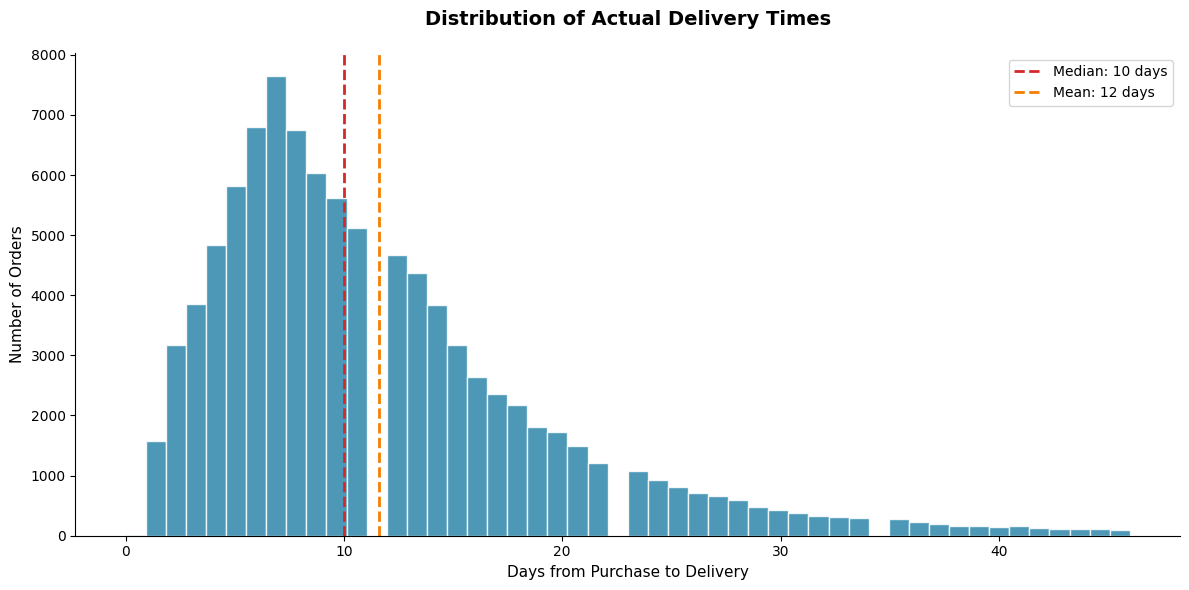

Chart saved ✅


In [14]:
fig, ax = plt.subplots(figsize=(12, 6))

# Cap at 99th percentile for visual clarity
cutoff = delivered['actual_delivery_days'].quantile(0.99)
data = delivered[delivered['actual_delivery_days'] <= cutoff]['actual_delivery_days']

ax.hist(data, bins=50, color='#2E86AB', edgecolor='white', alpha=0.85)
ax.axvline(data.median(), color='#D62828', linestyle='--', linewidth=2, 
           label=f'Median: {data.median():.0f} days')
ax.axvline(data.mean(), color='#F77F00', linestyle='--', linewidth=2, 
           label=f'Mean: {data.mean():.0f} days')

ax.set_xlabel('Days from Purchase to Delivery', fontsize=11)
ax.set_ylabel('Number of Orders', fontsize=11)
ax.set_title('Distribution of Actual Delivery Times', fontsize=14, weight='bold', pad=20)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend()

plt.tight_layout()
plt.savefig('../outputs/delivery_time_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved ✅")

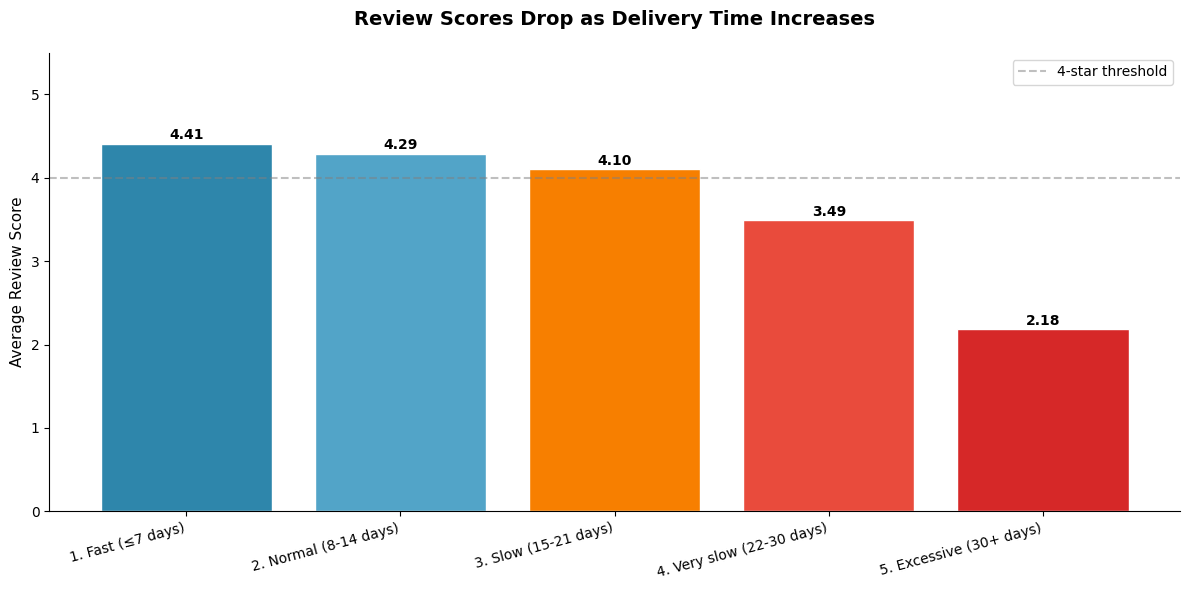

Chart saved ✅


In [15]:
fig, ax = plt.subplots(figsize=(12, 6))

# Sort by delivery bucket
plot_data = review_by_speed.copy()

bars = ax.bar(plot_data.index, plot_data['avg_review'], 
              color=['#2E86AB', '#52A4C8', '#F77F00', '#E94B3C', '#D62828'],
              edgecolor='white')

# Add value labels
for bar, value in zip(bars, plot_data['avg_review']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{value:.2f}', ha='center', fontsize=10, weight='bold')

ax.set_ylabel('Average Review Score', fontsize=11)
ax.set_title('Review Scores Drop as Delivery Time Increases', fontsize=14, weight='bold', pad=20)
ax.set_ylim(0, 5.5)
ax.axhline(y=4, color='gray', linestyle='--', alpha=0.5, label='4-star threshold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(rotation=15, ha='right')
ax.legend()

plt.tight_layout()
plt.savefig('../outputs/review_by_delivery_speed.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved ✅")

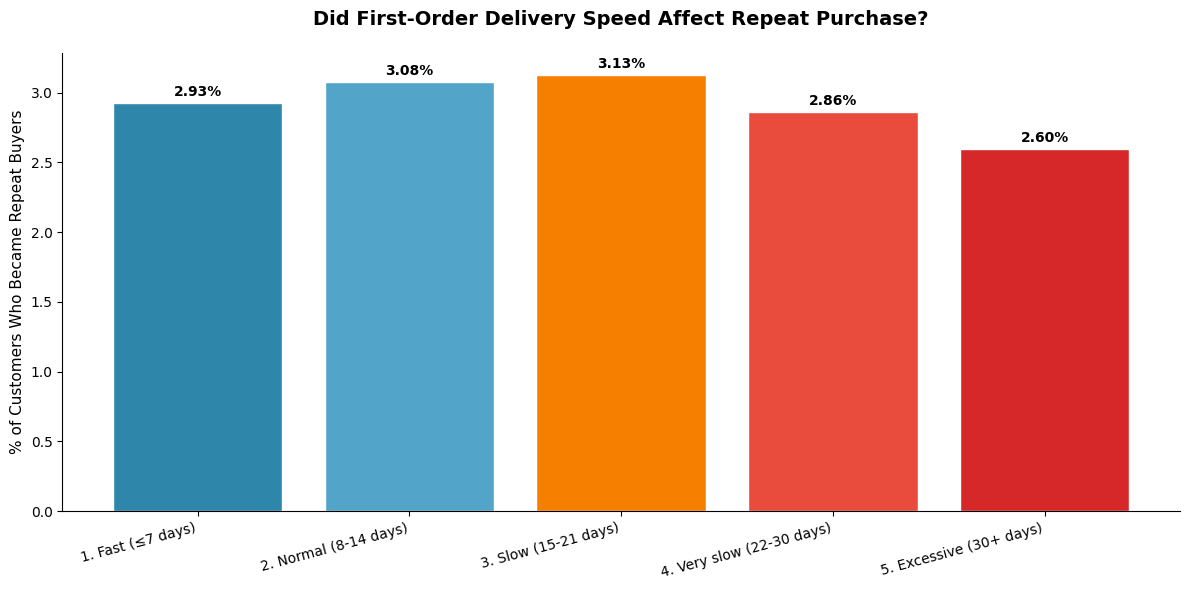

Chart saved ✅


In [16]:
fig, ax = plt.subplots(figsize=(12, 6))

plot_data = speed_vs_retention.copy()

bars = ax.bar(plot_data.index, plot_data['repeat_rate'], 
              color=['#2E86AB', '#52A4C8', '#F77F00', '#E94B3C', '#D62828'],
              edgecolor='white')

# Add value labels
for bar, value in zip(bars, plot_data['repeat_rate']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{value:.2f}%', ha='center', fontsize=10, weight='bold')

ax.set_ylabel('% of Customers Who Became Repeat Buyers', fontsize=11)
ax.set_title('Did First-Order Delivery Speed Affect Repeat Purchase?', 
             fontsize=14, weight='bold', pad=20)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(rotation=15, ha='right')

plt.tight_layout()
plt.savefig('../outputs/retention_by_delivery_speed.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved ✅")